In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
# Download the dataset (only needed once)
!wget -q https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv -O telco_churn.csv

df = pd.read_csv("telco_churn.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
print("Missing values per column:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Missing values per column:
customerID         0
gender             0
SeniorCitizen      0
Partner            0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
OnlineSecurity     0
dtype: int64


In [5]:

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())


df = df.drop(columns=["customerID"])

print(f"After cleaning shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")

After cleaning shape: (7043, 20)
Missing values: 0


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


/tmp/ipykernel_1335/822402365.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", palette="Set2")


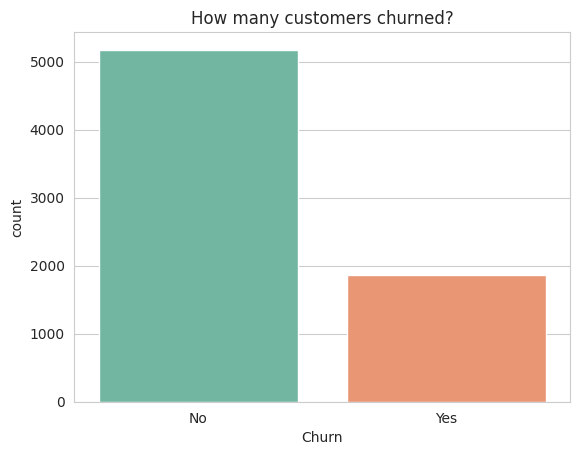

In [6]:
churn_rate = df["Churn"].value_counts(normalize=True) * 100
print(churn_rate)

sns.countplot(data=df, x="Churn", palette="Set2")
plt.title("How many customers churned?")
plt.show()

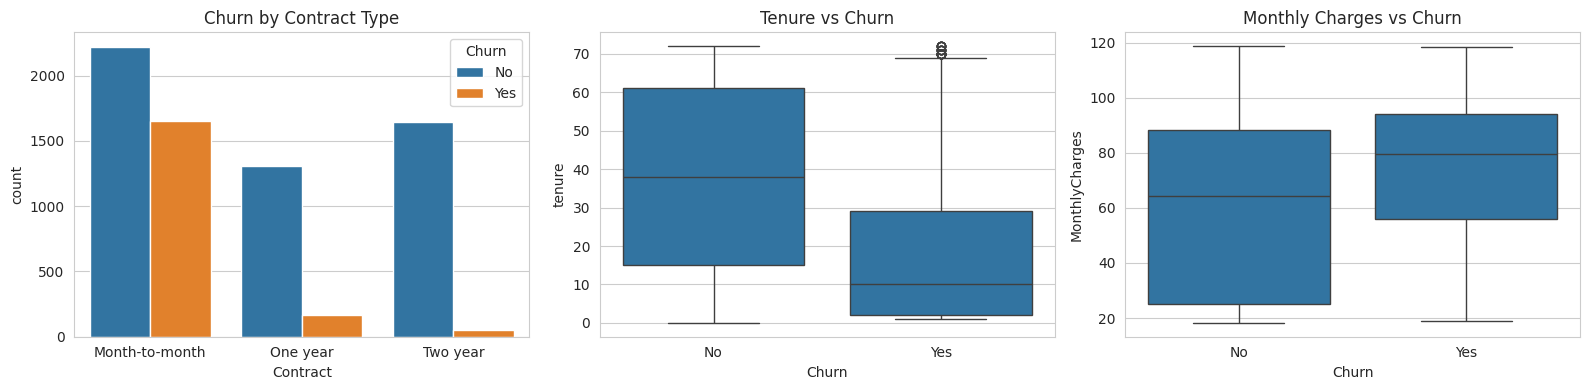

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(data=df, x="Contract", hue="Churn", ax=axes[0])
axes[0].set_title("Churn by Contract Type")

sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[1])
axes[1].set_title("Tenure vs Churn")

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[2])
axes[2].set_title("Monthly Charges vs Churn")

plt.tight_layout()
plt.show()

In [8]:

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

X = df.drop(columns=["Churn"])
y = df["Churn"]


num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print(f"Numeric columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")

Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (5634, 19)
Test size:  (1409, 19)


In [10]:
# Preprocessing: scale numbers, one-hot encode categories
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])


model = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    )),
])

print("✅ Pipeline ready")

✅ Pipeline ready


In [11]:
model.fit(X_train, y_train)
print("✅ Model trained!")

✅ Model trained!


In [12]:

probs = model.predict_proba(X_test)[:, 1]
preds = model.predict(X_test)

auc = roc_auc_score(y_test, probs)
print(f"ROC-AUC: {auc:.3f}\n")

print(classification_report(y_test, preds, target_names=["No Churn", "Churn"]))

ROC-AUC: 0.822

              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



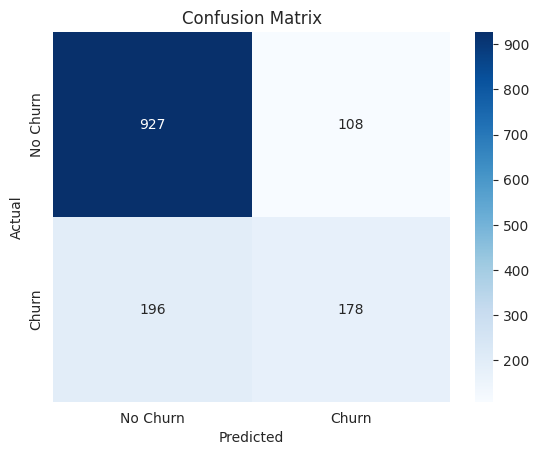

In [13]:
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

/tmp/ipykernel_1335/4146616026.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x="importance", y="feature", palette="viridis")


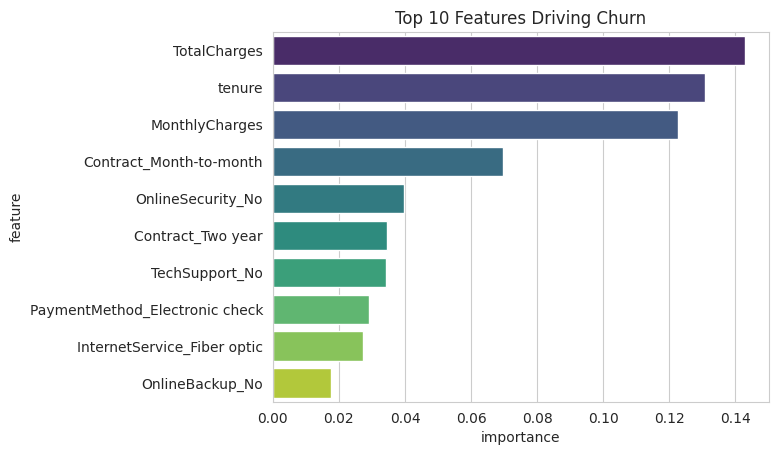

In [14]:

ohe = model.named_steps["prep"].named_transformers_["cat"]
cat_names = ohe.get_feature_names_out(cat_cols)
all_features = num_cols + list(cat_names)

importances = model.named_steps["clf"].feature_importances_

feat_df = pd.DataFrame({
    "feature": all_features,
    "importance": importances
}).sort_values("importance", ascending=False).head(10)

sns.barplot(data=feat_df, x="importance", y="feature", palette="viridis")
plt.title("Top 10 Features Driving Churn")
plt.show()

In [15]:
!pip install xgboost -q

from xgboost import XGBClassifier

xgb_model = Pipeline([
    ("prep", preprocessor),
    ("clf", XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        scale_pos_weight=3,
        eval_metric="logloss",
        random_state=42
    )),
])

xgb_model.fit(X_train, y_train)

xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_probs)
print(f"XGBoost ROC-AUC: {xgb_auc:.3f}")

XGBoost ROC-AUC: 0.824


           Model   ROC-AUC
1        XGBoost  0.824028
0  Random Forest  0.822301


/tmp/ipykernel_1335/3194555873.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x="Model", y="ROC-AUC", palette="Set1")


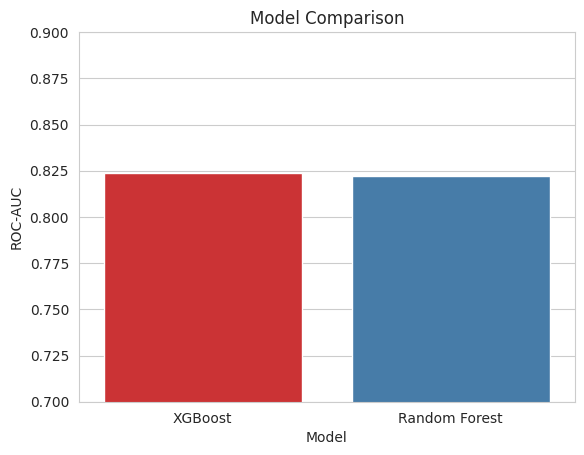

In [16]:
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "ROC-AUC": [auc, xgb_auc]
}).sort_values("ROC-AUC", ascending=False)

print(results)

sns.barplot(data=results, x="Model", y="ROC-AUC", palette="Set1")
plt.ylim(0.7, 0.9)
plt.title("Model Comparison")
plt.show()

In [17]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_dist = {
    "clf__n_estimators": randint(100, 500),
    "clf__max_depth": randint(3, 10),
    "clf__learning_rate": uniform(0.01, 0.2),
    "clf__subsample": uniform(0.6, 0.4),
    "clf__colsample_bytree": uniform(0.6, 0.4),
}

search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)

print(f"Best ROC-AUC (CV): {search.best_score_:.3f}")
print(f"Best params: {search.best_params_}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best ROC-AUC (CV): 0.848
Best params: {'clf__colsample_bytree': np.float64(0.6624074561769746), 'clf__learning_rate': np.float64(0.041198904067240534), 'clf__max_depth': 5, 'clf__n_estimators': 187, 'clf__subsample': np.float64(0.7334834444556088)}


In [18]:
best_model = search.best_estimator_
best_probs = best_model.predict_proba(X_test)[:, 1]
best_auc = roc_auc_score(y_test, best_probs)

print(f"Tuned XGBoost ROC-AUC: {best_auc:.3f}")


final = pd.DataFrame({
    "Model": ["Random Forest (baseline)", "XGBoost (default)", "XGBoost (tuned)"],
    "ROC-AUC": [auc, xgb_auc, best_auc]
}).sort_values("ROC-AUC", ascending=False)
print("\n", final)

Tuned XGBoost ROC-AUC: 0.842

                       Model   ROC-AUC
2           XGBoost (tuned)  0.842416
1         XGBoost (default)  0.824028
0  Random Forest (baseline)  0.822301


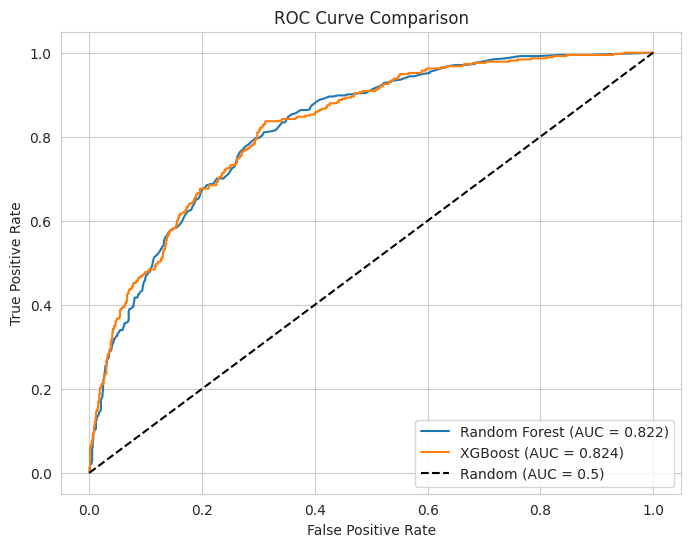

In [19]:
from sklearn.metrics import roc_curve

fpr_rf, tpr_rf, _ = roc_curve(y_test, probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {xgb_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.savefig("roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
import joblib


final_model = xgb_model if xgb_auc > auc else model
final_score = max(auc, xgb_auc)

joblib.dump(final_model, "churn_model.pkl")
print(f"✅ Saved best model (ROC-AUC: {final_score:.3f})")

✅ Saved best model (ROC-AUC: 0.824)


In [21]:
!pip install shap -q
import shap

In [22]:

best_model = search.best_estimator_

X_test_transformed = best_model.named_steps["prep"].transform(X_test)


ohe = best_model.named_steps["prep"].named_transformers_["cat"]
cat_names = ohe.get_feature_names_out(cat_cols)
feature_names = num_cols + list(cat_names)

print(f"Transformed shape: {X_test_transformed.shape}")
print(f"Total features after encoding: {len(feature_names)}")

Transformed shape: (1409, 45)
Total features after encoding: 45


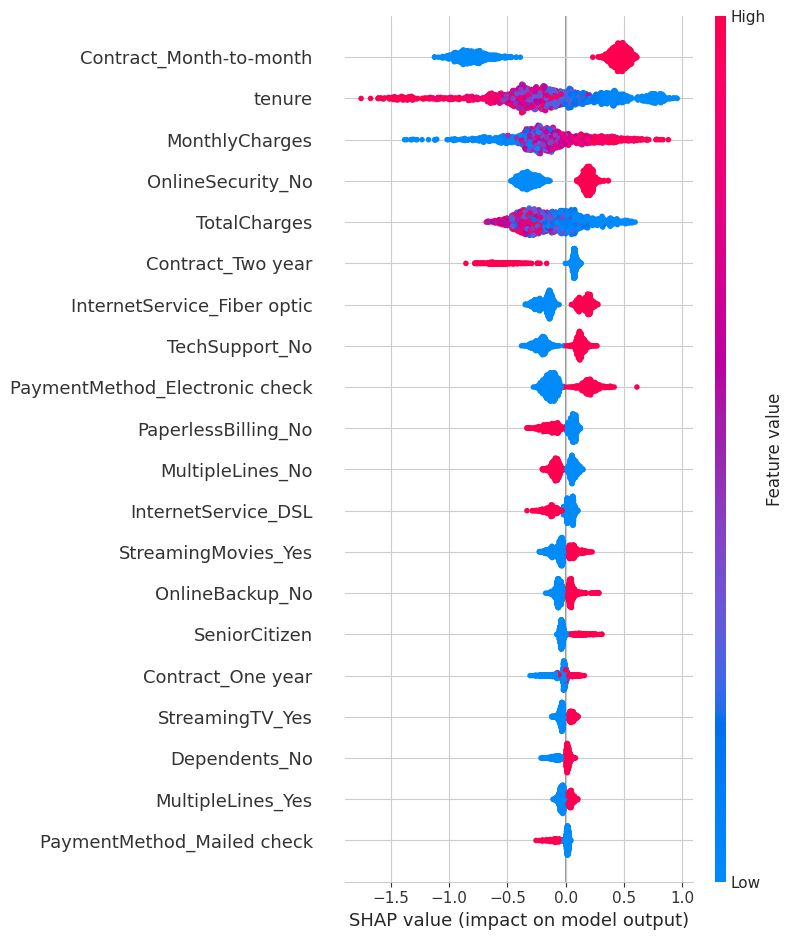

In [23]:

explainer = shap.TreeExplainer(best_model.named_steps["clf"])


shap_values = explainer.shap_values(X_test_transformed)


shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    show=True
)

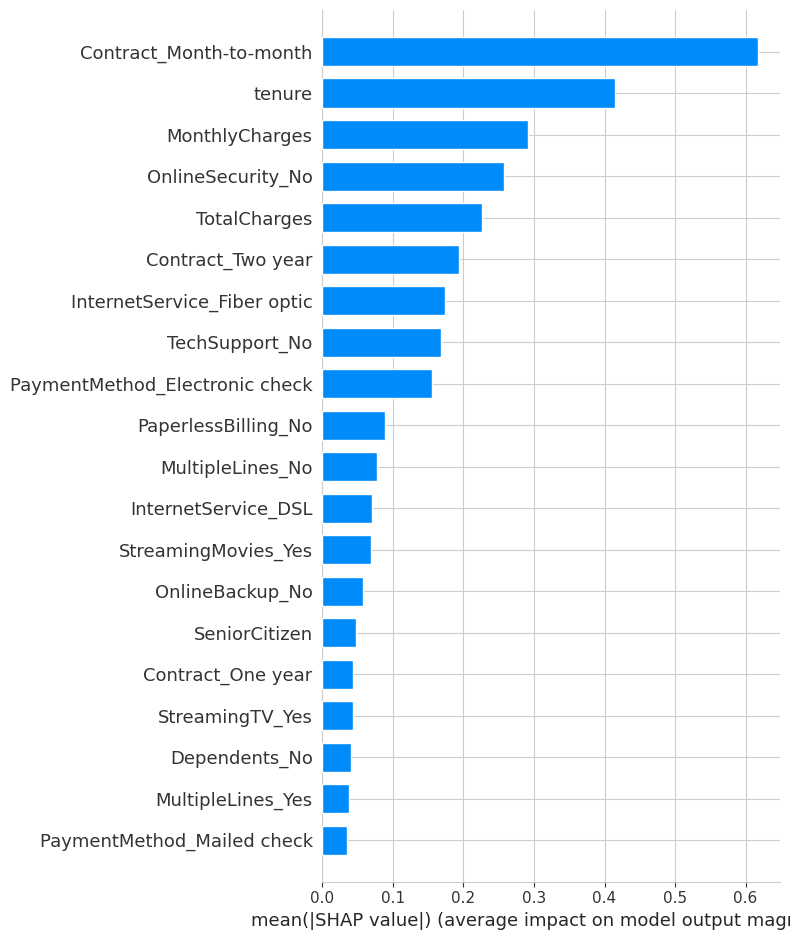

In [24]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)

Customer details:
gender                               Female
SeniorCitizen                             0
Partner                                  No
Dependents                               No
tenure                                   21
PhoneService                            Yes
MultipleLines                           Yes
InternetService                 Fiber optic
OnlineSecurity                           No
OnlineBackup                            Yes
DeviceProtection                         No
TechSupport                              No
StreamingTV                             Yes
StreamingMovies                         Yes
Contract                     Month-to-month
PaperlessBilling                        Yes
PaymentMethod       Credit card (automatic)
MonthlyCharges                        99.85
TotalCharges                        1992.55
Name: 5748, dtype: object

Actual churn: 0
Predicted probability: 0.831


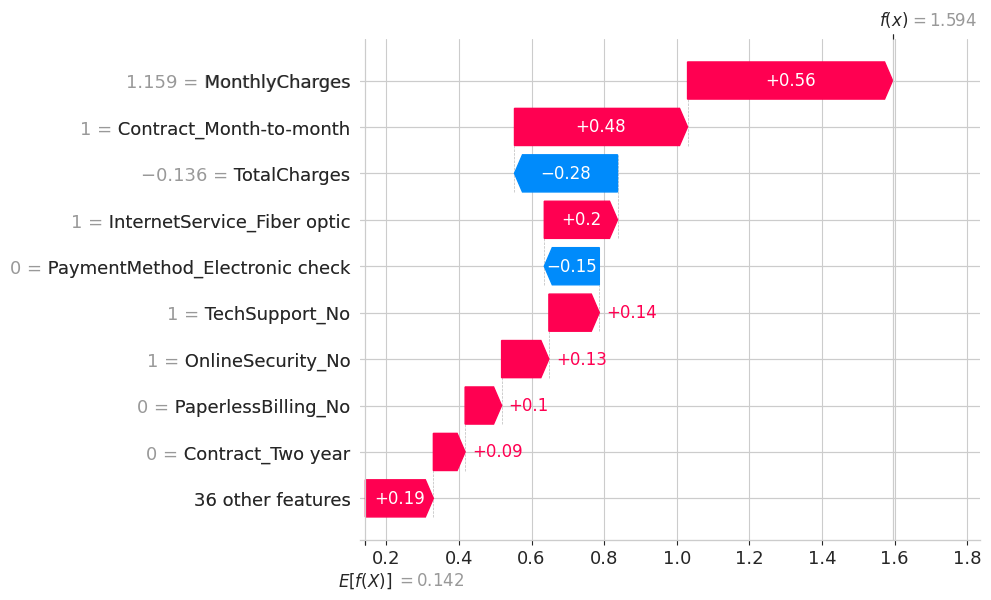

In [25]:

customer_idx = 5

print("Customer details:")
print(X_test.iloc[customer_idx])
print(f"\nActual churn: {y_test.iloc[customer_idx]}")
print(f"Predicted probability: {best_probs[customer_idx]:.3f}")


shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[customer_idx],
        base_values=explainer.expected_value,
        data=X_test_transformed[customer_idx],
        feature_names=feature_names
    )
)

In [26]:

importance_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).head(10)

print("Top 10 churn drivers:")
print(importance_df.to_string(index=False))

Top 10 churn drivers:
                       feature  mean_abs_shap
       Contract_Month-to-month       0.617880
                        tenure       0.415146
                MonthlyCharges       0.291143
             OnlineSecurity_No       0.256933
                  TotalCharges       0.226502
             Contract_Two year       0.193913
   InternetService_Fiber optic       0.173842
                TechSupport_No       0.168124
PaymentMethod_Electronic check       0.155168
           PaperlessBilling_No       0.088872


In [27]:
import joblib
import json
from google.colab import files


joblib.dump(best_model, "churn_model.pkl")


metadata = {
    "model_type": "XGBoost (tuned)",
    "roc_auc": float(best_auc),
    "top_features": importance_df["feature"].head(10).tolist(),
    "feature_names": feature_names,
    "num_cols": num_cols,
    "cat_cols": cat_cols,
}
with open("model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)


files.download("churn_model.pkl")
files.download("model_metadata.json")

print("✅ Downloaded model + metadata")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded model + metadata


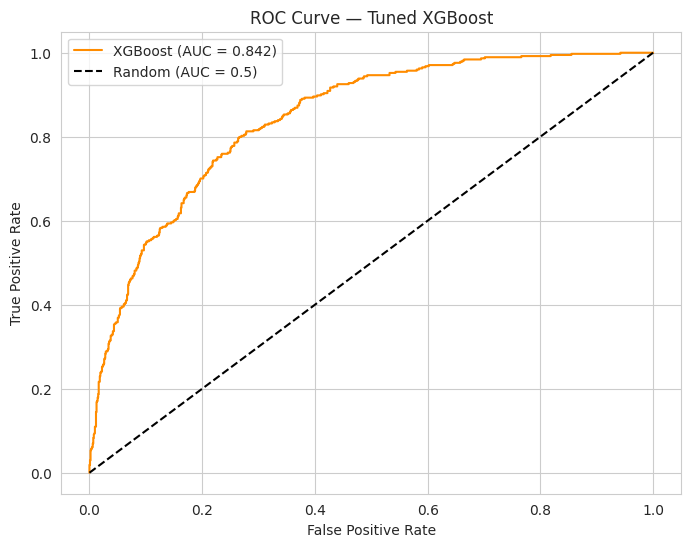

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded charts


In [28]:

shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=feature_names, plot_type="bar", show=False)
plt.savefig("shap_importance.png", dpi=150, bbox_inches="tight")
plt.close()


plt.figure(figsize=(8, 6))
from sklearn.metrics import roc_curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, best_probs)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {best_auc:.3f})", color="darkorange")
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Tuned XGBoost")
plt.legend()
plt.grid(True)
plt.savefig("roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

files.download("shap_importance.png")
files.download("roc_curve.png")

print("✅ Downloaded charts")